# Part 4 – Offshore Wind Park Development and Construction [9 pts]
OE44170 Offshore Renewable Technologies – Assignment: Electrical Aspects

Part 4 is qualitative. This notebook
1. structures the stakeholder analysis (risks, opportunities, mitigation strategy) as a table that is exported
   to LaTeX for the report, and
2. supports the construction-sequence argument with a schedule (Gantt chart) and a simple, **illustrative**
   cash-flow comparison of two installation sequences.

The park of Part 3 (66 × 12 MVA ≈ 792 MW) is used as the example project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIG = Path("report/figures/electrical"); FIG.mkdir(parents=True, exist_ok=True)
TAB = Path("report/tables"); TAB.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

## 1. Stakeholder analysis

In [2]:
stakeholders = pd.DataFrame([
    ["National government",
     "Political/reputational risk if the first project is delayed, over budget or meets public resistance; fiscal risk if a subsidy (CfD/SDE-type) is required.",
     "Contribution to climate and renewable targets, energy security and less import dependence; start of a national offshore wind industry and jobs.",
     "Early alignment on permitting, tender and support scheme; share data openly; propose the project as the national ‘pilot’ with a lessons-learned programme."],
    ["Local government",
     "Visual impact on the coastline and possible effect on tourism and property values; nuisance from onshore cable route and substation works.",
     "Local jobs, business rates/taxes, community fund, upgraded port and grid infrastructure, image as a ‘green’ region.",
     "Visualisations from the coast and public consultations early; route onshore works to minimise nuisance; community benefit fund and local co-ownership."],
    ["Nature conservation society",
     "Bird and bat collisions, underwater noise during pile driving (marine mammals), habitat disturbance from cables and scour protection.",
     "Artificial reef effect and nature-inclusive design, no-trawling zone as de-facto marine protected area, monitoring data, displacement of fossil generation.",
     "Thorough EIA with baseline surveys; mitigation (bubble curtains, soft-start, seasonal piling windows, curtailment during bird migration); fund joint monitoring."],
    ["Local fishermen",
     "Loss of fishing grounds and longer sailing routes; risk of gear snagging on cables; reduced catch during construction.",
     "Compensation, guard-vessel and survey contracts during construction and O&M, passive fishing/aquaculture within the park, higher fish stock near foundations.",
     "Fisheries liaison officer from day one; adequate cable burial and as-built data; compensation scheme and paid work for local vessels; co-use agreements."],
    ["Local port",
     "Congestion and conflicts with existing users; investment in quays/storage that may not pay back if no follow-up projects come.",
     "Marshalling and O&M base for decades: new revenue, jobs, positioning as offshore wind hub for future projects.",
     "Long-term lease/O&M contract that de-risks port investments; early agreement on quay strength, laydown area and schedule."],
    ["Grid company (TSO)",
     "Grid congestion and balancing effort due to variable output; required onshore reinforcements; technical risk of a first offshore connection (reactive power, harmonics).",
     "Large new generation close to the coast, learning on offshore grid standards; possible reuse of offshore substation for future grid hub/interconnector.",
     "Grid connection agreement and studies at an early stage; comply with grid code (fault ride-through, reactive power, HWRT); stagger energisation; share forecasts."],
], columns=["Stakeholder", "Possible risk", "Possible gain / opportunity", "Developer strategy"])
pd.set_option("display.max_colwidth", None)
stakeholders

,Stakeholder,Possible risk,Possible gain / opportunity,Developer strategy
0,National government,"Political/reputational risk if the first project is delayed, over budget or meets public resistance; fiscal risk if a subsidy (CfD/SDE-type) is required.","Contribution to climate and renewable targets, energy security and less import dependence; start of a national offshore wind industry and jobs.","Early alignment on permitting, tender and support scheme; share data openly; propose the project as the national ‘pilot’ with a lessons-learned programme."
1,Local government,Visual impact on the coastline and possible effect on tourism and property values; nuisance from onshore cable route and substation works.,"Local jobs, business rates/taxes, community fund, upgraded port and grid infrastructure, image as a ‘green’ region.",Visualisations from the coast and public consultations early; route onshore works to minimise nuisance; community benefit fund and local co-ownership.
2,Nature conservation society,"Bird and bat collisions, underwater noise during pile driving (marine mammals), habitat disturbance from cables and scour protection.","Artificial reef effect and nature-inclusive design, no-trawling zone as de-facto marine protected area, monitoring data, displacement of fossil generation.","Thorough EIA with baseline surveys; mitigation (bubble curtains, soft-start, seasonal piling windows, curtailment during bird migration); fund joint monitoring."
3,Local fishermen,Loss of fishing grounds and longer sailing routes; risk of gear snagging on cables; reduced catch during construction.,"Compensation, guard-vessel and survey contracts during construction and O&M, passive fishing/aquaculture within the park, higher fish stock near foundations.",Fisheries liaison officer from day one; adequate cable burial and as-built data; compensation scheme and paid work for local vessels; co-use agreements.
4,Local port,Congestion and conflicts with existing users; investment in quays/storage that may not pay back if no follow-up projects come.,"Marshalling and O&M base for decades: new revenue, jobs, positioning as offshore wind hub for future projects.","Long-term lease/O&M contract that de-risks port investments; early agreement on quay strength, laydown area and schedule."
5,Grid company (TSO),"Grid congestion and balancing effort due to variable output; required onshore reinforcements; technical risk of a first offshore connection (reactive power, harmonics).","Large new generation close to the coast, learning on offshore grid standards; possible reuse of offshore substation for future grid hub/interconnector.","Grid connection agreement and studies at an early stage; comply with grid code (fault ride-through, reactive power, HWRT); stagger energisation; share forecasts."


In [3]:
# export to LaTeX (tabularx body) for the report
def tex_escape(s):
    return (s.replace("&", "\\&").replace("%", "\\%").replace("‘", "`").replace("’", "'")
             .replace("–", "--").replace("—", "---"))
rows = [" & ".join(tex_escape(str(x)) for x in r.values[:3]) + " \\\\\n" for _, r in stakeholders.iterrows()]
with open(TAB / "p4_stakeholders.tex", "w", encoding="utf8") as f:
    f.write("\\hline\n".join(rows))
print(open(TAB / "p4_stakeholders.tex", encoding="utf8").read()[:500])

National government & Political/reputational risk if the first project is delayed, over budget or meets public resistance; fiscal risk if a subsidy (CfD/SDE-type) is required. & Contribution to climate and renewable targets, energy security and less import dependence; start of a national offshore wind industry and jobs. \\
\hline
Local government & Visual impact on the coastline and possible effect on tourism and property values; nuisance from onshore cable route and substation works. & Local jo


## 2. Construction sequence – schedule
Proposed order (see report for the argumentation):
1. Onshore substation + grid connection (longest lead time, onshore permits; start first)
2. Export cables (offshore → onshore)
3. Offshore substation (foundation + topside), energised from shore
4. WTG foundations (can run in parallel with 2–3 as soon as vessels and weather allow)
5. Inter-array cables (follow the foundations string by string)
6. Wind turbines (each string produces as soon as the WTGs are commissioned → early revenue)

Durations are indicative, inspired by the Windpark Fryslân timeline shown in the lecture
(2019 export cable + substation, 2020 foundations + IAC, 2021 IAC + WTGs).

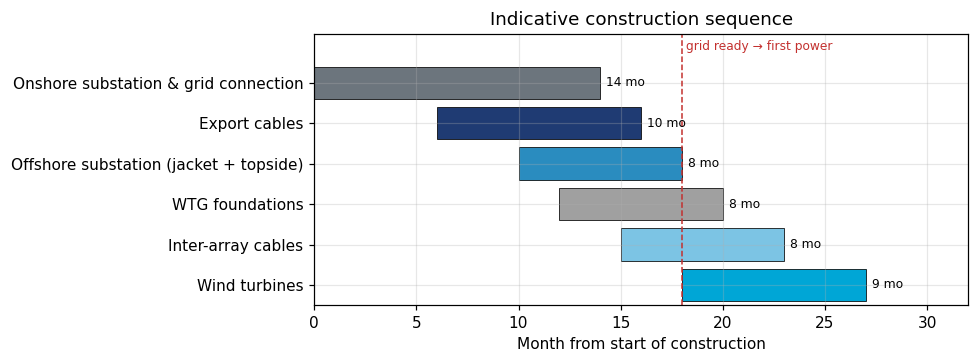

In [4]:
tasks = [  # name, start [month], duration [months]
    ("Onshore substation & grid connection", 0, 14),
    ("Export cables", 6, 10),
    ("Offshore substation (jacket + topside)", 10, 8),
    ("WTG foundations", 12, 8),
    ("Inter-array cables", 15, 8),
    ("Wind turbines", 18, 9),
]
colors = ["#6c757d", "#1f3b73", "#2a8cbf", "#a0a0a0", "#7cc4e4", "#00a6d6"]
fig, ax = plt.subplots(figsize=(9, 3.4))
for i, ((n, s, d), c) in enumerate(zip(tasks, colors)):
    ax.barh(i, d, left=s, color=c, edgecolor="k", lw=0.5)
    ax.text(s + d + 0.3, i, f"{d} mo", va="center", fontsize=8)
ax.axvline(18, color="#c3312f", ls="--", lw=1); ax.text(18.2, -0.8, "grid ready → first power", color="#c3312f", fontsize=8)
ax.set_yticks(range(len(tasks))); ax.set_yticklabels([t[0] for t in tasks]); ax.invert_yaxis()
ax.set_xlabel("Month from start of construction"); ax.set_xlim(0, 32); ax.set_ylim(len(tasks) - 0.5, -1.2)
ax.set_title("Indicative construction sequence")
fig.tight_layout(); fig.savefig(FIG / "p4_construction_gantt.png"); plt.show()

## 3. Why this order maximises profitability – illustrative cash-flow comparison
Two sequences with the **same** WTG installation campaign (9 months, WTGs commissioned uniformly):
* **A – grid first:** export system energised before the first WTG is installed → every WTG produces
  immediately after commissioning.
* **B – grid last:** the export system is completed only after the WTG campaign → WTGs stand idle
  (no revenue, need diesel generators for heating/dehumidification).

Assumptions (illustrative): 792 MW, capacity factor 46 % (Part 1), electricity price 70 EUR/MWh,
discount rate 7 %/yr.

Discounted revenue up to month 47:  A (grid first) = EUR 399 M | B (grid last) = EUR 223 M | difference = EUR 176 M


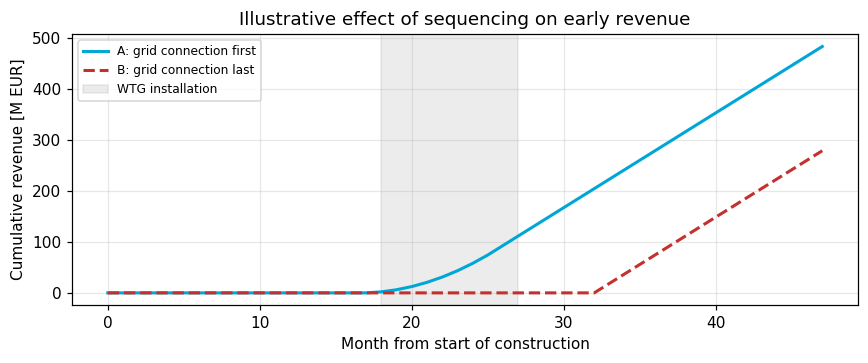

In [5]:
P_MW, CF, price, r = 792, 0.46, 70, 0.07
months = np.arange(0, 48)
inst_start, inst_dur = 18, 9
installed_frac = np.clip((months - inst_start + 1) / inst_dur, 0, 1)
grid_ready_B = inst_start + inst_dur + 6    # grid completed 6 months after last WTG in sequence B

hours_per_month = 8760 / 12
rev_A = installed_frac * P_MW * CF * hours_per_month * price / 1e6
rev_B = np.where(months >= grid_ready_B, installed_frac, 0) * P_MW * CF * hours_per_month * price / 1e6
disc = (1 + r) ** (-months / 12)
npv_A, npv_B = (rev_A * disc).sum(), (rev_B * disc).sum()
print(f"Discounted revenue up to month {months[-1]}:  A (grid first) = EUR {npv_A:,.0f} M | "
      f"B (grid last) = EUR {npv_B:,.0f} M | difference = EUR {npv_A-npv_B:,.0f} M")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(months, np.cumsum(rev_A), color="#00a6d6", lw=2, label="A: grid connection first")
ax.plot(months, np.cumsum(rev_B), color="#c3312f", lw=2, ls="--", label="B: grid connection last")
ax.axvspan(inst_start, inst_start + inst_dur, color="grey", alpha=0.15, label="WTG installation")
ax.set_xlabel("Month from start of construction"); ax.set_ylabel("Cumulative revenue [M EUR]")
ax.legend(loc="upper left", fontsize=8); ax.set_title("Illustrative effect of sequencing on early revenue")
fig.tight_layout(); fig.savefig(FIG / "p4_revenue_sequence.png"); plt.show()